In [1]:
import json
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import json
import time

import sys
sys.path.insert(0, '../..')

from rb_clf_V2.scripts.utils import plot_config
from rb_clf_V2.scripts.train_RBclf import load_single, get_akb_labels

In [2]:
plot_config()

In [3]:
oids, features = load_single('../../dr23-features/sid_snad_clf_r_100.dat', '../../dr23-features/feature_rb_no-chi2.dat')
rb_score = np.array(features[:, -1])

In [5]:
proba_file = '../../dr23-features/RBclf_proba.dat'
rb_score_old = np.memmap(proba_file, mode='c', dtype=np.float32)


Text(0, 0.5, 'Density')

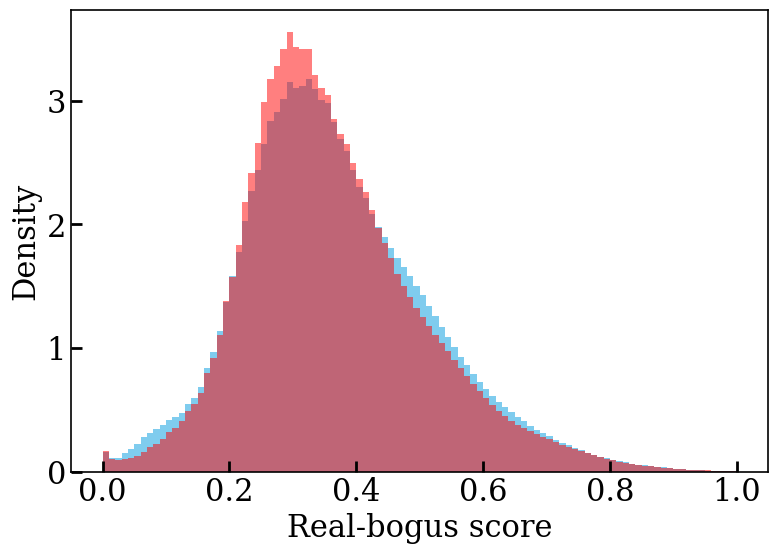

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(rb_score, bins=100, density=True, label='dr23-features',  alpha=0.5,  color=u'#009ADE')
ax.hist(rb_score_old, bins=100, density=True, label='dr23-features',  alpha=0.5,  color='red')
plt.xlabel('Real-bogus score')
plt.ylabel('Density')
#plt.text(0.55, 5.7, 'Objects number: 67m')
#plt.legend()
#plt.savefig('plots/snad4/rb_score_hist_bigfont.pdf', dpi=400, format='pdf', bbox_inches="tight")

In [7]:
akb = get_akb_labels(f'../data/akb.ztf.snad.space.json')

crossmatch = np.load(f'../data/crossmatch.npy')
akb_proba = rb_score[crossmatch] 
akb_labels = np.array([akb[oid] for oid in oids[crossmatch]])

Text(0, 0.5, 'Density')

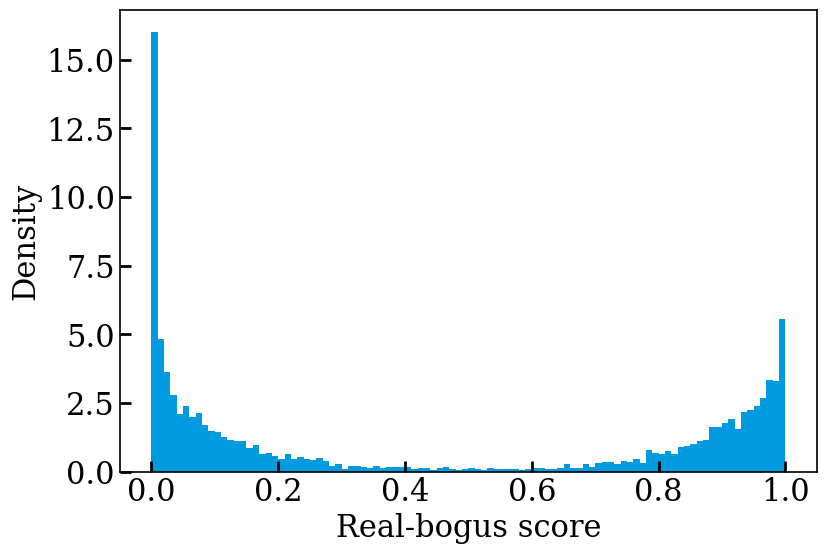

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(akb_proba, bins=100, density=True, label='dr23-features',  alpha=1,  color=u'#009ADE')
plt.xlabel('Real-bogus score')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

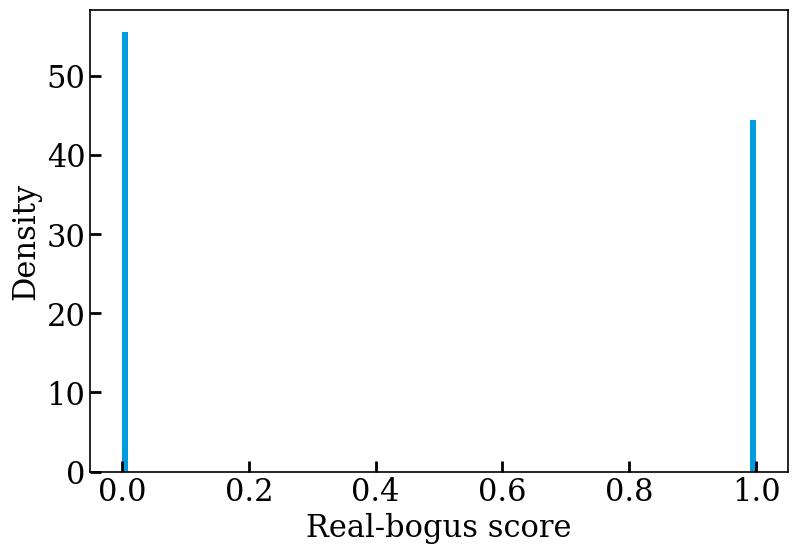

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(akb_labels, bins=100, density=True, label='dr23-features',  alpha=1,  color=u'#009ADE')
plt.xlabel('Real-bogus score')
plt.ylabel('Density')